## Imports

In [1]:
import argparse
import os
import pathlib
import sys

import napari

# import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage.io as io
import tifffile
from image_analysis_3D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_3D.file_utils.file_reading import (
    find_files_available,
    read_in_channels,
)
from image_analysis_3D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from napari.utils import nbscreenshot

root_dir, in_notebook = init_notebook()

image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

sys.path.append(f"{root_dir}/utils")
from image_analysis_3D.segmentation_utils.segmentation_decoupling import (
    euclidian_2D_distance,
)

In [ ]:
if not in_notebook:
    args = parse_args()
    well_fov = args["well_fov"]
    patient = args["patient"]
    input_subparent_name = args["input_subparent_name"]
    mask_subparent_name = args["mask_subparent_name"]
    check_for_missing_args(
        well_fov=well_fov,
        patient=patient,
        input_subparent_name=input_subparent_name,
        mask_subparent_name=mask_subparent_name,
    )
else:
    print("Running in a notebook")
    patient = "NF0014_T1"
    well_fov = "E7-2"
    input_subparent_name = "zstack_images"
    mask_subparent_name = "segmentation_masks"
image_dir = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{input_subparent_name}/{well_fov}/"
).resolve(strict=True)
label_dir = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{mask_subparent_name}/{well_fov}/"
).resolve(strict=True)

Running in a notebook


In [3]:
label_dir
output_path = "output.zarr"
channel_map = {
    "405": "Nuclei",
    "488": "Endoplasmic Reticulum",
    "555": "Actin, Golgi, and plasma membrane (AGP)",
    "640": "Mitochondria",
    "TRANS": "Brightfield",
}
scaling_values = [1, 0.1, 0.1]

In [4]:
image_return_dict = read_in_channels(
    find_files_available(image_dir),
    channel_dict={
        "DNA": "405",
        "Endoplasmic Reticulum": "488",
        "AGP": "555",
        "Mitochondria": "640",
    },
    channels_to_read=[
        "DNA",
        "Endoplasmic Reticulum",
        "AGP",
        "Mitochondria",
    ],
)

mask_return_dict = read_in_channels(
    find_files_available(label_dir),
    channel_dict={
        "Nuclei mask": "nuclei",
        "Cell mask": "cell",
        "Cytoplasm mask": "cytoplasm",
        "Organoid mask": "organoid",
    },
    channels_to_read=[
        "Nuclei mask",
        "Cell mask",
        "Cytoplasm mask",
        "Organoid mask",
    ],
)

/home/lippincm/Documents/fork2_NF1_3D_organoid_profiling_pipeline/.venv/lib/python3.13/site-packages/skimage/util/dtype.py:529: UserWarning: Downcasting int64 to uint16 without scaling because max value 15 fits in uint16
  return _convert(image, np.uint16, force_copy)


In [5]:
headless = False
viewer = napari.Viewer(ndisplay=3, show=bool(not headless))

In [6]:
image_metadata = f"{patient}_{well_fov}"

In [7]:
for image_name, image_array in image_return_dict.items():
    viewer.add_image(
        image_array,
        name=f"{image_metadata}_{image_name}",
        scale=scaling_values,
    )
for mask_name, mask_array in mask_return_dict.items():
    viewer.add_labels(
        mask_array,
        name=f"{image_metadata}_{mask_name}",
        scale=scaling_values,
    )

In [8]:
# toggle view for all labels except organoid
for layer in viewer.layers:
    if "organoid" not in layer.name.lower():
        layer.visible = False

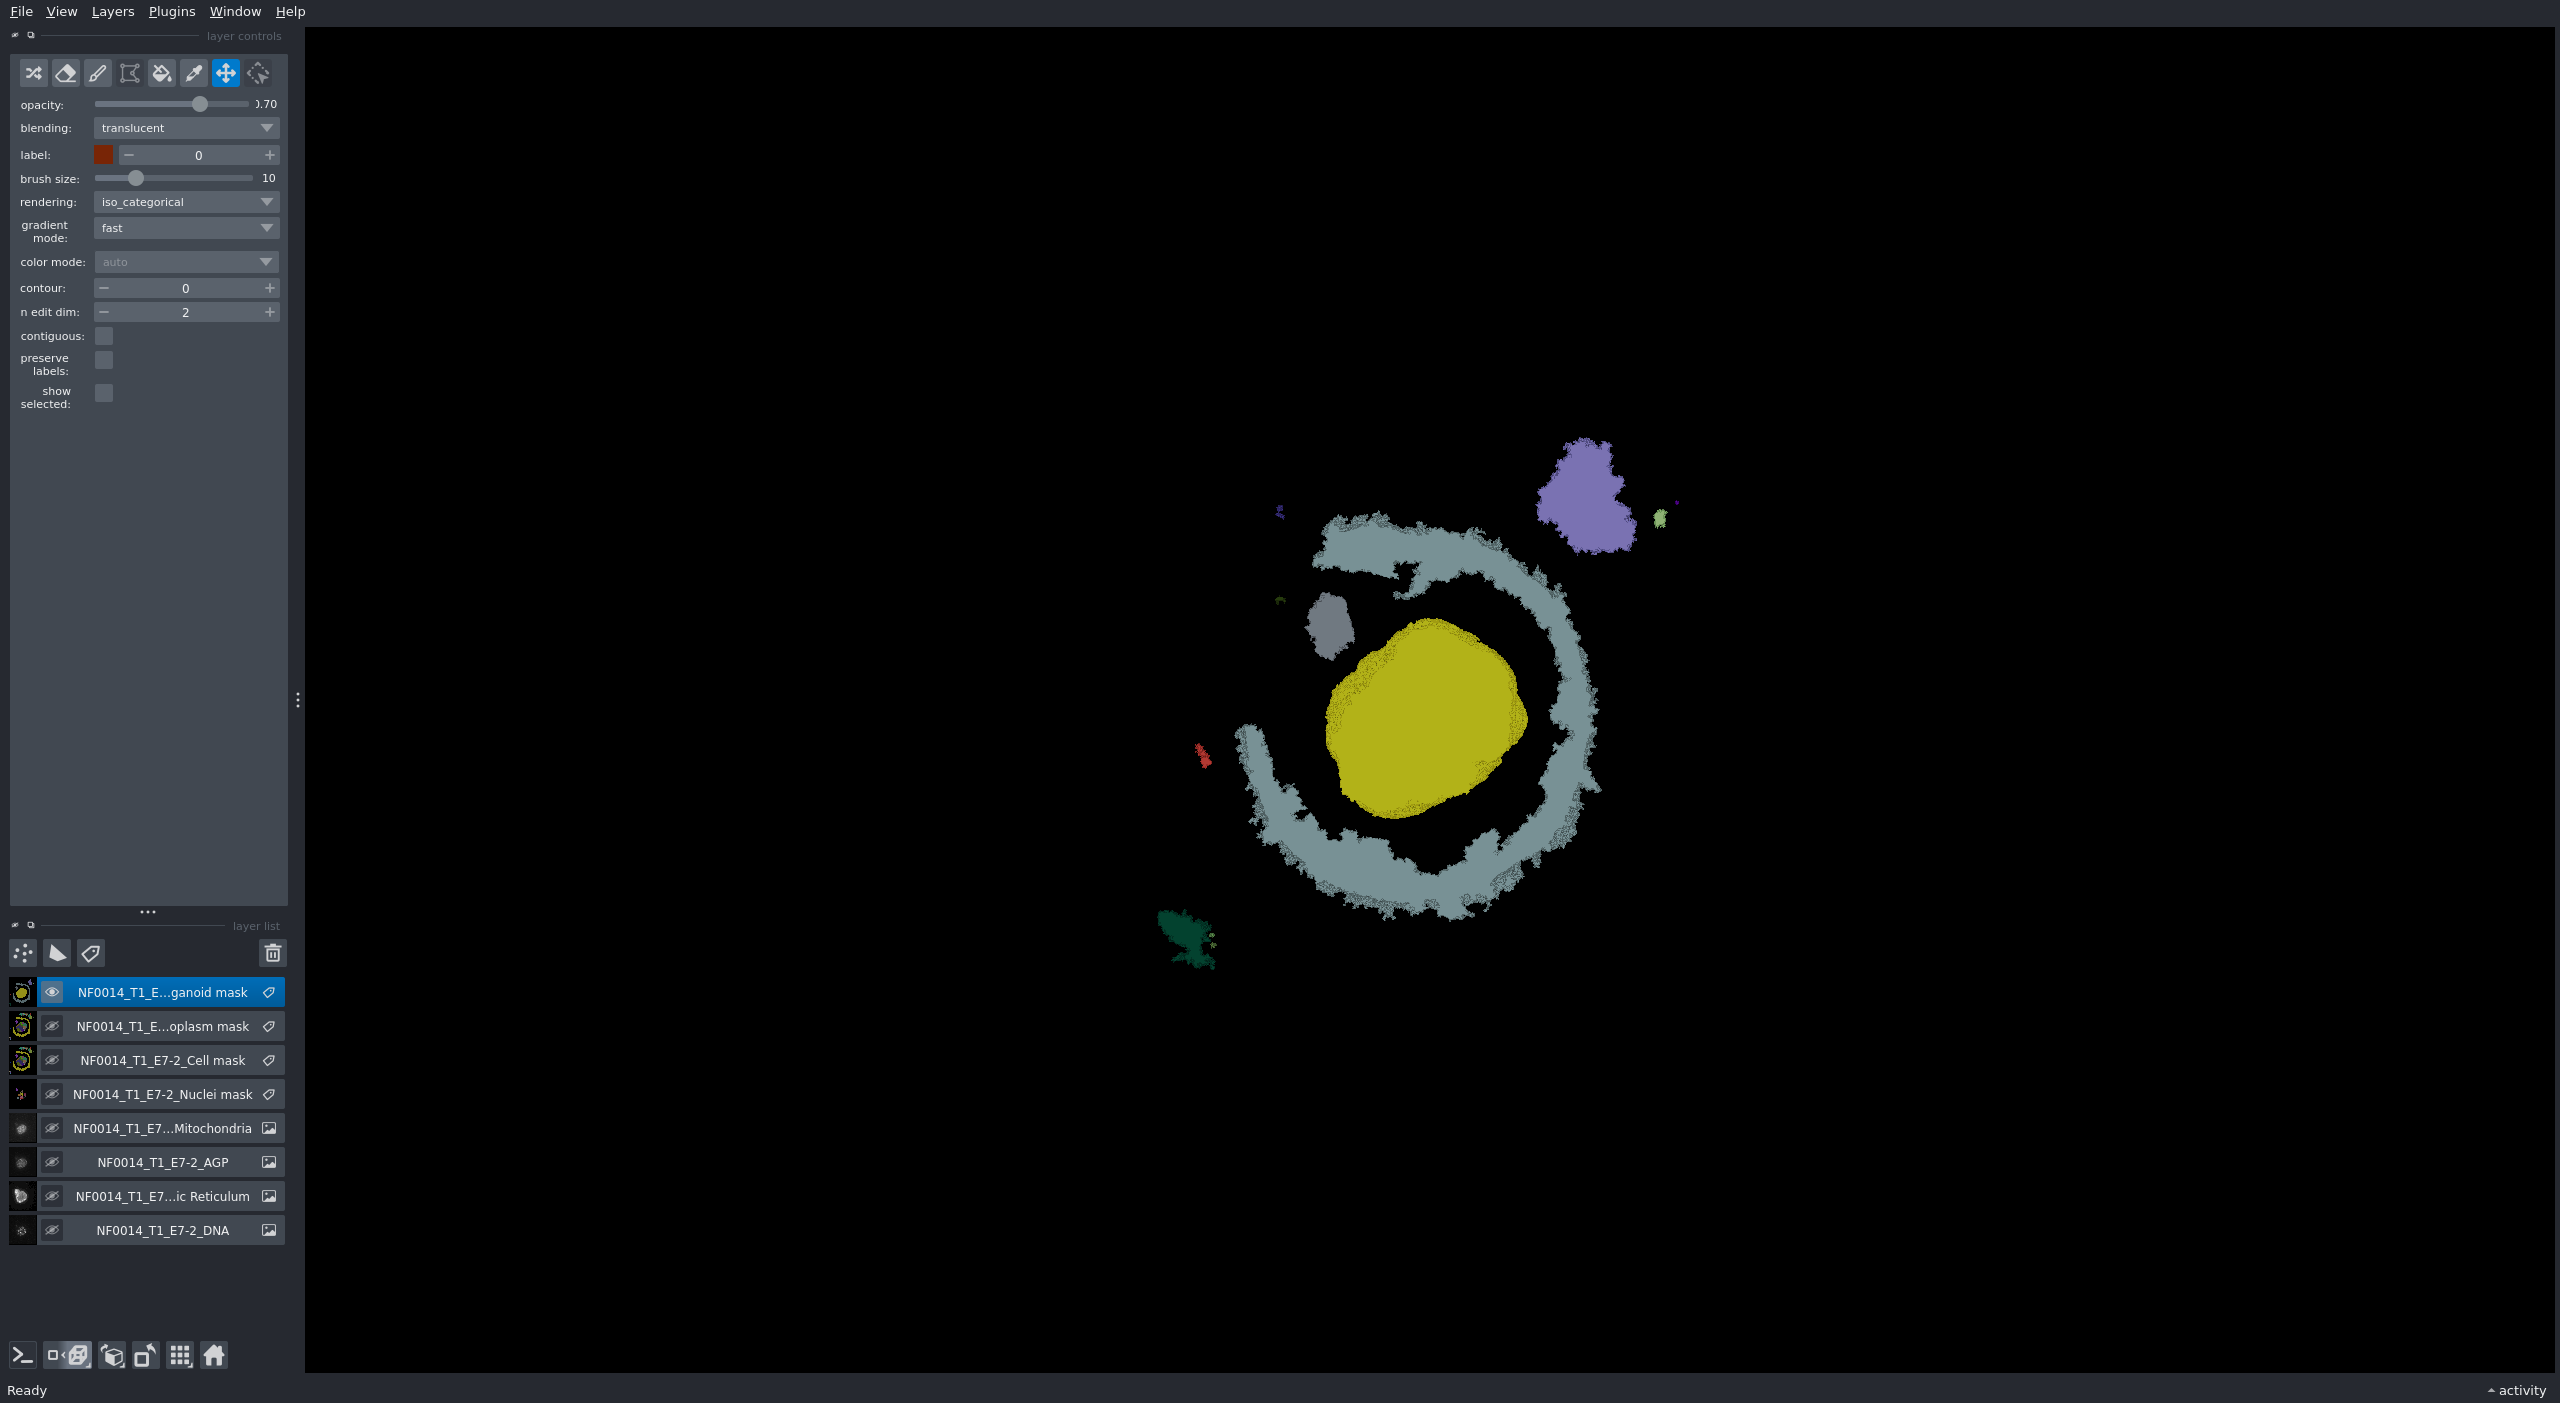

In [9]:
# screenshot the napari viewer
nbscreenshot(viewer)